# Using GeoEnthalpyDelta component for alluvial fan simulation

Builds alluvial fans set up where the feeder cells change over time

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

from landlab import RasterModelGrid
from landlab.components import GeoEnthalpyDelta

%matplotlib inline
from landlab.plot import imshow_grid

## Theory
> Visit the geoenthalpy_delta for building a simple delta fan for details about the theory

For this tutorial, we will leverage the capability of the delta model to use it for terrestial application such as an alluvial fan. This case, we must assume there is no sea level, can the level can be set to be negative and below our basement elevation.

## Grid setup

For this example, we only need a small size grid so 50x50 looks good enough.
Setting up the grid using the Landlab grid component.

We also want to extract x axis so we can set up a basement for the model.
Since the basement is a plannar with a downhill slope, we have it slope `m=-1`

```basement = -mx```

In [2]:
from landlab.components import LinearDiffuser

nrows, ncols = 100, 50
dx = dy = 0.2
grid = RasterModelGrid((nrows, ncols), xy_spacing=dx) # hummm no option for (dx,dy)?

x = grid.x_of_node.reshape(grid.shape)
basement = grid.add_zeros("basement__elevation", at="node")
m1 = -1
m2 = 0.02
break_at = ncols*dx / 3
x_flat = x.reshape(-1)
basement[:] = np.where(
    x_flat <= break_at,
    m1 * x_flat,
    m1 * break_at + m2 * (x_flat - break_at),
)
np.random.seed(50)
grid.at_node['basement__elevation'] = basement + np.random.rand(basement.size)/2
grid.at_node["topographic__elevation"] = grid.at_node["basement__elevation"].copy()

# small diffusion
diffuser = LinearDiffuser(grid, linear_diffusivity=0.05)
# pick a stable small timestep (fallback if attribute name differs)
dt_diff = 0.5 * dx**2 / getattr(diffuser, "linear_diffusivity", 0.05)
diffuser.run_one_step(dt_diff)

# copy back the slightly diffused basement
grid.at_node["basement__elevation"] = grid.at_node["topographic__elevation"].copy()

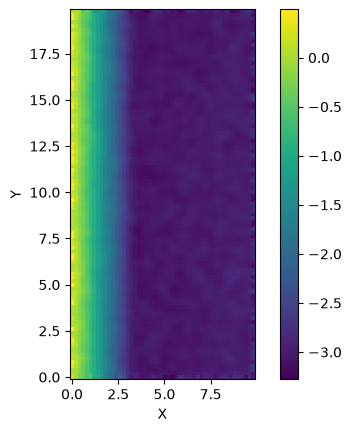

In [3]:
imshow_grid(grid, "basement__elevation", cmap="viridis")

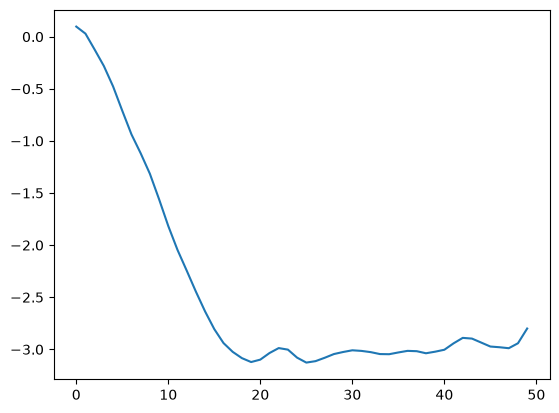

In [4]:
plt.plot(grid.at_node['basement__elevation'].reshape(grid.shape)[5,:])

## How does feeder_mask work inside the GeoEnthalpyDelta component?

We first read in the first row of the y axis. The default setup of the `feeder_mask` is by comparing each row's y-coordinate against a target `feeder_y_center` (by default the midpoint of the grid's y-extent) and marking every row within `0.5 * feeder_width` of that center as `True`. 

The result is a single boolean array of length nrows telling run_one_step which rows to inject sediment_flux into as upstream flux.

> You aren't limited to this single, centered band. `run_one_step` takes an optional `feeder_mask` keyword that overrides which rows are active, for that call, and for every call after, until you override it again. For example, if you have a record of how a river's terminus or distributary mouths migrate laterally over time, you can recompute the mask at each step (or at whatever interval your data resolves) and pass the updated mask in as `feeder_mask=<your mask>`

We don't have a continuous migration record here, so instead we synthetically build two different static masks, `mod_feeder_mask` and `another_mod_feeder_mask`, and switch between them at fixed steps inside the run loop below. 

A couple of things to watch for when writing your own mask:

> Its length must equal the number of grid rows (grid.shape[0]).

> It must contain at least one `True` entry.

In [5]:
y_of_row = grid.y_of_node.reshape(grid.shape)[:, 0]

In [6]:
feeder_y_center = 0.5 * (y_of_row.min() + y_of_row.max())

In [7]:
mod_feeder_mask = (np.abs(y_of_row - feeder_y_center) <= 0.5 * 1.0 + 1.0)

In [8]:
mod_feeder_mask = [False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       True, True, True, True, True, True, True, False, False,
       False, False, False, False, False, False,  False,  False,  False,
        False,  False,  False,  False,  False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, True,  True,  True,  True,  True,
        True,  True,  True,  True, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False]

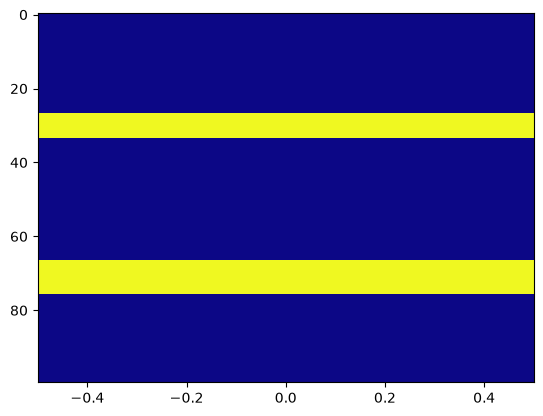

In [9]:
plt.imshow(np.array(mod_feeder_mask).reshape((100,1)), cmap="plasma", aspect="auto")

In [10]:
another_mod_feeder_mask = [False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
        False, False,
       False, False, False, False, False, False,  False,  False,  False,
        True, True, True, True, True, True, True,False,  False,  False,  False,  False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, True,  True,  True,  True,  True,
        True,  True,  True,  True, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False]

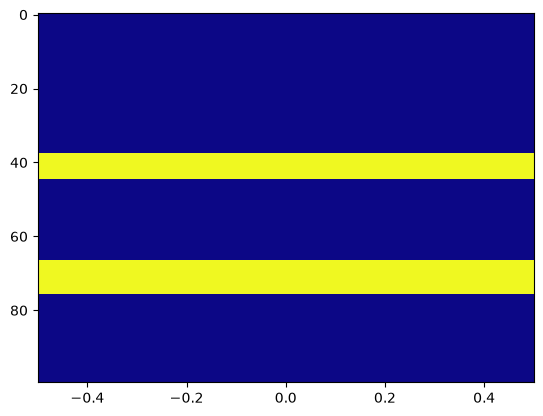

In [11]:
plt.imshow(np.array(another_mod_feeder_mask).reshape((100,1)), cmap="plasma", aspect="auto")

## Calling GeoEnthalpyDelta component

In [12]:
sea_level = -4.0
esd = GeoEnthalpyDelta(
    grid,
    sediment_flux=0.5,
    feeder_width=1.0,
    sea_level_start=sea_level,
    sea_level_rise_rate=0.0,
    topset_threshold_x=0.3,
    topset_threshold_y=0.2,
    foreset_threshold_x=2.0,
    foreset_threshold_y=2.0,
    topset_diffusivity_x=1.0,
    topset_diffusivity_y=1.0,
    foreset_diffusivity_x=1.0,
    foreset_diffusivity_y=1.0,
)

dt = esd.calc_stable_time_step()
nsteps = 5000
print(f"dt = {dt:.5g}, running {nsteps} steps (t_end = {nsteps * dt:.3g}) ...")

dt = 0.004, running 5000 steps (t_end = 20) ...


This will take a while, but your should see `done in #.# s` meaning the run is completed

In [13]:
t0 = time.time()
volume_history = []
time_history = []

In [14]:
for step in range(nsteps):
    if step == 1000:
            esd.run_one_step(dt, feeder_mask = mod_feeder_mask)
    elif step == 3500:
        esd.run_one_step(dt, feeder_mask = another_mod_feeder_mask)
    else:
        esd.run_one_step(dt)
    if step % 25 == 0:
        vol = np.sum(grid.at_node["sediment__thickness"]) * dx * dy
        volume_history.append(vol)
        time_history.append(esd.time_elapsed)
print(f"done in {time.time() - t0:.2f} s")

done in 41.40 s


## Mass Balance
Checking if the final output match with the expected output

In [15]:
expected_volume = 0.5 * nsteps * dt
final_volume = np.sum(grid.at_node["sediment__thickness"]) * dx * dy
np.isclose(final_volume, expected_volume, rtol=1e-6)


np.True_

Check the 3 output of the component 
1. basement__elevation

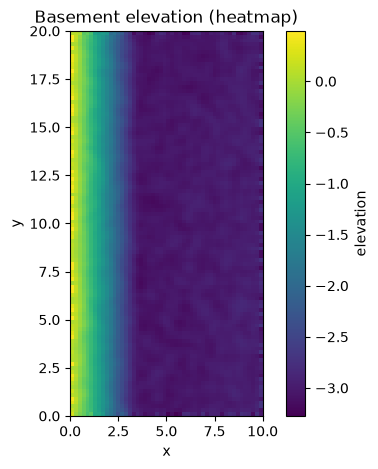

In [16]:
basement = grid.at_node["basement__elevation"].reshape(grid.shape)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(basement, origin="lower", extent=(0, ncols * dx, 0, nrows * dy),
               cmap="viridis", aspect="equal")
ax.set_title("Basement elevation (heatmap)")
ax.set_xlabel("x")
ax.set_ylabel("y")
fig.colorbar(im, ax=ax, label="elevation")
plt.show()

2. `grid.at_node["sediment__thickness"]`


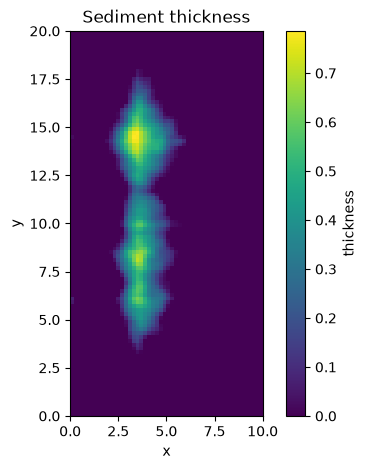

In [17]:
Hthickness = grid.at_node["sediment__thickness"].reshape(grid.shape)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(Hthickness, origin="lower", extent=(0, ncols * dx, 0, nrows * dy),
               cmap="viridis", aspect="equal")
ax.set_title("Sediment thickness")
ax.set_xlabel("x")
ax.set_ylabel("y")
fig.colorbar(im, ax=ax, label="thickness")
plt.show()

3. `grid.at_node["topographic__elevation"]`

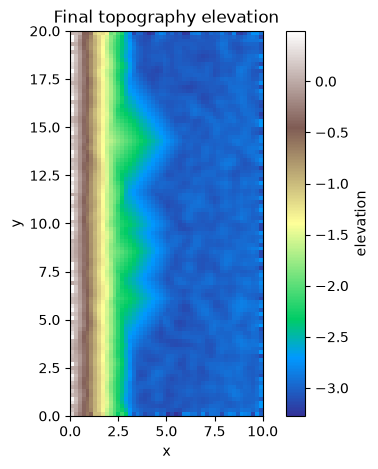

In [18]:
final_topography = grid.at_node["topographic__elevation"].reshape(grid.shape)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(final_topography, origin="lower", extent=(0, ncols * dx, 0, nrows * dy),
               cmap="terrain", aspect="equal")
ax.set_title("Final topography elevation")
ax.set_xlabel("x")
ax.set_ylabel("y")
fig.colorbar(im, ax=ax, label="elevation")
plt.show()

## Comprehensive Plots

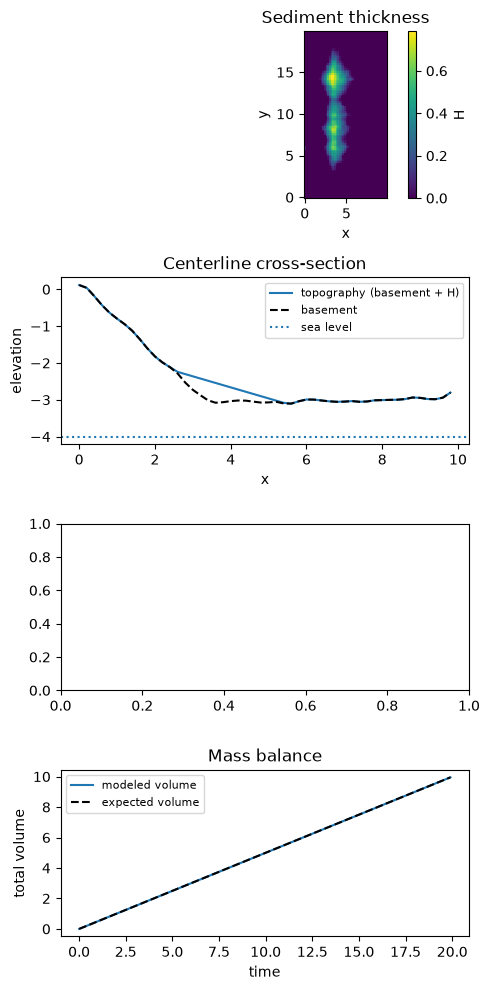

In [19]:
H = Hthickness
eta = final_topography
final_sea_level = sea_level + esd.sea_level_rise_rate * esd.time_elapsed
X = grid.x_of_node.reshape(grid.shape)
Y = grid.y_of_node.reshape(grid.shape)
j_mid = nrows // 2
i_mid = ncols // 3

fig, axes = plt.subplots(4, 1, figsize=(5, 10))

im = axes[0].pcolormesh(X, Y, H, shading="auto", cmap="viridis")
axes[0].set_title("Sediment thickness")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_aspect("equal")
fig.colorbar(im, ax=axes[0], label="H")

axes[1].plot(X[j_mid], eta[j_mid], label="topography (basement + H)")
axes[1].plot(X[j_mid], basement[j_mid],
             "k--", label="basement")
axes[1].axhline(final_sea_level,color="tab:blue",linestyle=":",label="sea level")
axes[1].set_title("Centerline cross-section")
axes[1].set_xlabel("x")
axes[1].set_ylabel("elevation")
axes[1].legend(fontsize=8)

# axes[2].plot(Y[i_mid], eta[i_mid], label="topography (basement + H)")
# axes[2].plot(Y[i_mid], basement[i_mid],
#              "k--", label="basement")
# axes[2].axhline(final_sea_level,color="tab:blue",linestyle=":",label="sea level")
# axes[2].set_title("Centerline cross-section")
# axes[2].set_xlabel("y")
# axes[2].set_ylabel("elevation")
# axes[2].legend(fontsize=8)

axes[3].plot(time_history, volume_history, label="modeled volume")
axes[3].plot(time_history, [0.5 * t for t in time_history], "k--", label="expected volume")
axes[3].set_title("Mass balance")
axes[3].set_xlabel("time")
axes[3].set_ylabel("total volume")
axes[3].legend(fontsize=8)

fig.tight_layout()